Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("CARDIOVASCULAR DISEASE - DATA CLEANING & PREPROCESSING")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================
df = pd.read_excel(r"D:\ROUT\ML\final project\Book1.xlsx")

print(f"✓ Data loaded successfully!")
print(f"  Shape: {df.shape}")
print(f"  Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe())


CARDIOVASCULAR DISEASE - DATA CLEANING & PREPROCESSING
✓ Data loaded successfully!
  Shape: (63703, 13)
  Rows: 63,703 | Columns: 13

First 5 rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63703 entries, 0 to 63702
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id

In [3]:

# ============================================================================
# STEP 2: CHECK DATA QUALITY
# ============================================================================
# Check missing values
print("\n Missing Values Check:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"Total missing values: {missing_values.sum()}")

if missing_values.sum() == 0:
    print("No missing values found!")
else:
    print(" Found missing values - handling them...")
    # Handle if needed
    df = df.dropna()
    print(f" Dropped rows with missing values")
    print(f"  New shape: {df.shape}")


 Missing Values Check:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Total missing values: 0
No missing values found!


In [5]:


# ============================================================================
# STEP 3: CHECK duplicates
# ============================================================================
# Check duplicates
print("\n Duplicate Rows Check:")
duplicates = df.duplicated().sum()
print(f"  Duplicates found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")
    print(f"  New shape: {df.shape}")
else:
    print("No duplicates found!")


 Duplicate Rows Check:
  Duplicates found: 0
No duplicates found!


In [7]:
# ============================================================================
# STEP 4: DATA CLEANING - OUTLIER REMOVAL
# ============================================================================
original_size = len(df)
print(f"Dataset size before cleaning: {original_size:,}")

# Clean Height outliers
print("\n Cleaning Height (realistic range: 140-200 cm)")
print(f"  Before: {len(df):,} rows")
print(f"  Min: {df['height'].min()}, Max: {df['height'].max()}")
df = df[(df['height'] >= 140) & (df['height'] <= 200)]
print(f"  After: {len(df):,} rows")
print(f"  Removed: {original_size - len(df):,} rows")

# Clean Weight outliers
print("\nCleaning Weight (realistic range: 40-200 kg)")
weight_before = len(df)
print(f"  Before: {len(df):,} rows")
print(f"  Min: {df['weight'].min()}, Max: {df['weight'].max()}")
df = df[(df['weight'] >= 40) & (df['weight'] <= 200)]
print(f"  After: {len(df):,} rows")
print(f"  Removed: {weight_before - len(df):,} rows")

# Clean Systolic BP outliers
print("\n Cleaning Systolic BP (realistic range: 90-200 mmHg)")
bp_hi_before = len(df)
print(f"  Before: {len(df):,} rows")
print(f"  Min: {df['ap_hi'].min()}, Max: {df['ap_hi'].max()}")
df = df[(df['ap_hi'] >= 90) & (df['ap_hi'] <= 200)]
print(f"  After: {len(df):,} rows")
print(f"  Removed: {bp_hi_before - len(df):,} rows")

# Clean Diastolic BP outliers
print("\n Cleaning Diastolic BP (realistic range: 50-130 mmHg)")
bp_lo_before = len(df)
print(f"  Before: {len(df):,} rows")
print(f"  Min: {df['ap_lo'].min()}, Max: {df['ap_lo'].max()}")
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 130)]
print(f"  After: {len(df):,} rows")
print(f"  Removed: {bp_lo_before - len(df):,} rows")

# BP Logic Check (Systolic > Diastolic)
print("\n Blood Pressure Logic Check (Systolic > Diastolic)")
bp_logic_before = len(df)
print(f"  Before: {len(df):,} rows")
df = df[df['ap_hi'] > df['ap_lo']]
print(f"  After: {len(df):,} rows")
print(f"  Removed: {bp_logic_before - len(df):,} rows")

# Pulse Pressure Check
print("\n Pulse Pressure Check (20-100 mmHg)")
df['temp_pulse'] = df['ap_hi'] - df['ap_lo']
pulse_before = len(df)
print(f"  Before: {len(df):,} rows")
df = df[(df['temp_pulse'] >= 20) & (df['temp_pulse'] <= 100)]
print(f"  After: {len(df):,} rows")
print(f"  Removed: {pulse_before - len(df):,} rows")
df = df.drop('temp_pulse', axis=1)

# Summary
total_removed = original_size - len(df)
print("\n" + "-"*80)
print(" CLEANING SUMMARY:")
print(f"  Original size: {original_size:,}")
print(f"  Final size: {len(df):,}")
print(f"  Total removed: {total_removed:,} ({(total_removed/original_size)*100:.2f}%)")
print(f"  Data retained: {(len(df)/original_size)*100:.2f}%")


Dataset size before cleaning: 63,703

 Cleaning Height (realistic range: 140-200 cm)
  Before: 63,703 rows
  Min: 55, Max: 250
  After: 63,562 rows
  Removed: 141 rows

Cleaning Weight (realistic range: 40-200 kg)
  Before: 63,562 rows
  Min: 10.0, Max: 200.0
  After: 63,518 rows
  Removed: 44 rows

 Cleaning Systolic BP (realistic range: 90-200 mmHg)
  Before: 63,518 rows
  Min: -150, Max: 16020
  After: 63,141 rows
  Removed: 377 rows

 Cleaning Diastolic BP (realistic range: 50-130 mmHg)
  Before: 63,141 rows
  Min: 0, Max: 11000
  After: 62,197 rows
  Removed: 944 rows

 Blood Pressure Logic Check (Systolic > Diastolic)
  Before: 62,197 rows
  After: 62,184 rows
  Removed: 13 rows

 Pulse Pressure Check (20-100 mmHg)
  Before: 62,184 rows
  After: 62,058 rows
  Removed: 126 rows

--------------------------------------------------------------------------------
 CLEANING SUMMARY:
  Original size: 63,703
  Final size: 62,058
  Total removed: 1,645 (2.58%)
  Data retained: 97.42%


In [9]:

# ============================================================================
# STEP 5: FEATURE ENGINEERING
# ============================================================================


print("\n Creating New Features...")

# 1. Age in years
df['age'] = (df['age'] / 365.25).round(1)
print(" Converted age from days to years")

# 2. BMI
df['bmi'] = (df['weight'] / ((df['height']/100) ** 2)).round(2)
print(" Created BMI")

# Remove extreme BMI
bmi_before = len(df)
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 50)]
print(f"  Removed {bmi_before - len(df)} extreme BMI outliers")

# 3. Mean Arterial Pressure
df['map'] = ((df['ap_hi'] + 2 * df['ap_lo']) / 3).round(1)
print(" Created MAP (Mean Arterial Pressure)")

# 4. Pulse Pressure
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
print(" Created Pulse Pressure")

# 5. BP Category
df['bp_category'] = 0
df.loc[(df['ap_hi'] >= 120) | (df['ap_lo'] >= 80), 'bp_category'] = 1
df.loc[(df['ap_hi'] >= 130) | (df['ap_lo'] >= 85), 'bp_category'] = 2
df.loc[(df['ap_hi'] >= 140) | (df['ap_lo'] >= 90), 'bp_category'] = 3
print(" Created BP Category")

# 6. BMI Category
df['bmi_cat'] = 0
df.loc[df['bmi'] < 18.5, 'bmi_cat'] = 1
df.loc[df['bmi'] >= 25, 'bmi_cat'] = 2
df.loc[df['bmi'] >= 30, 'bmi_cat'] = 3
print(" Created BMI Category")

# 7. Age Category
df['age_cat'] = 0
df.loc[df['age'] >= 45, 'age_cat'] = 1
df.loc[df['age'] >= 55, 'age_cat'] = 2
df.loc[df['age'] >= 65, 'age_cat'] = 3
print(" Created Age Category")

# 8. Risk Factors Count
df['risk_factors'] = (
    (df['cholesterol'] > 1).astype(int) +
    (df['gluc'] > 1).astype(int) +
    df['smoke'] +
    df['alco'] +
    (df['active'] == 0).astype(int) +
    (df['bmi'] >= 30).astype(int)
)
print(" Created Risk Factors Count")

# 9. Interaction Features
df['age_bmi'] = (df['age'] * df['bmi']).round(2)
df['age_bp'] = (df['age'] * df['map']).round(2)
df['bmi_bp'] = (df['bmi'] * df['map']).round(2)
print(" Created Interaction Features (age_bmi, age_bp, bmi_bp)")

# 10. Health Score
df['health_score'] = (
    (df['cholesterol'] - 1) * 2 +
    (df['gluc'] - 1) * 2 +
    df['smoke'] * 3 +
    df['alco'] * 2 +
    (df['active'] == 0).astype(int) * 2 +
    (df['bmi_cat'] - 1).clip(0) * 2 +
    df['bp_category'] * 3
)
print(" Created Health Score")

print(f"\n Total features now: {df.shape[1]}")
print(f" Feature engineering complete!")



 Creating New Features...
 Converted age from days to years
 Created BMI
  Removed 145 extreme BMI outliers
 Created MAP (Mean Arterial Pressure)
 Created Pulse Pressure
 Created BP Category
 Created BMI Category
 Created Age Category
 Created Risk Factors Count
 Created Interaction Features (age_bmi, age_bp, bmi_bp)
 Created Health Score

 Total features now: 24
 Feature engineering complete!



 Target Distribution:
cardio
0    31313
1    30600
Name: count, dtype: int64

Percentage:
cardio
0    50.575808
1    49.424192
Name: proportion, dtype: float64

Saved: eda_overview.png


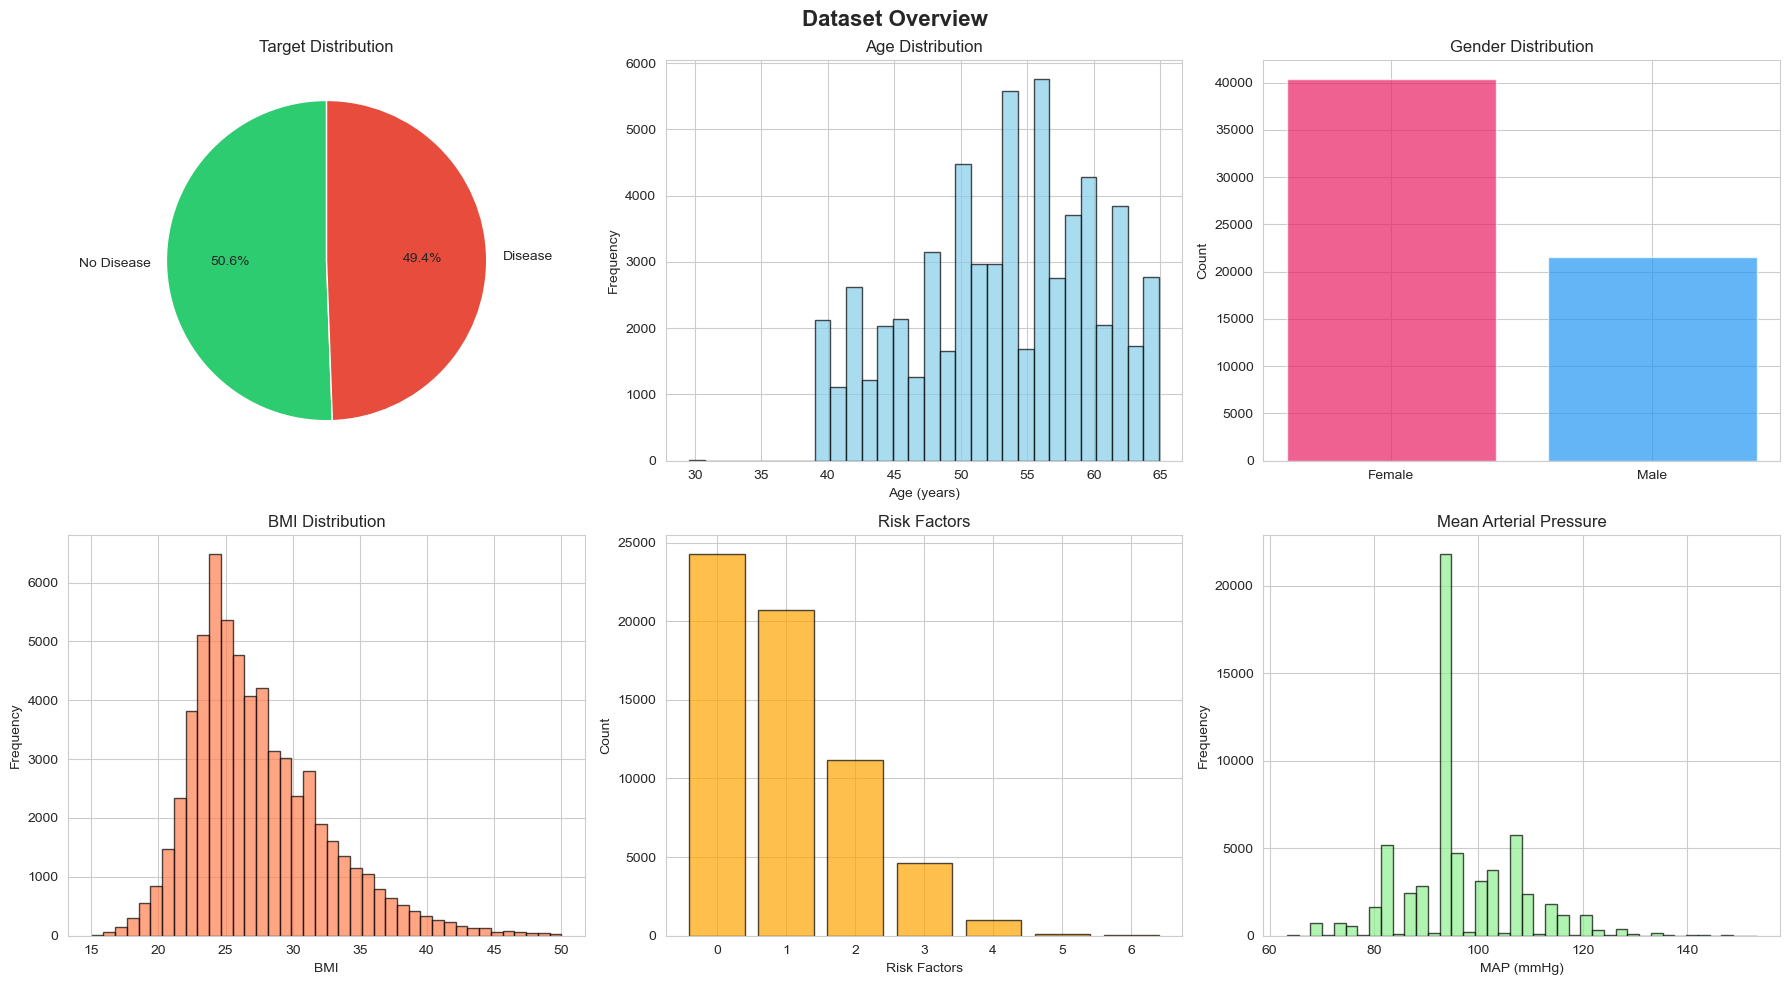

 Saved: disease_analysis.png


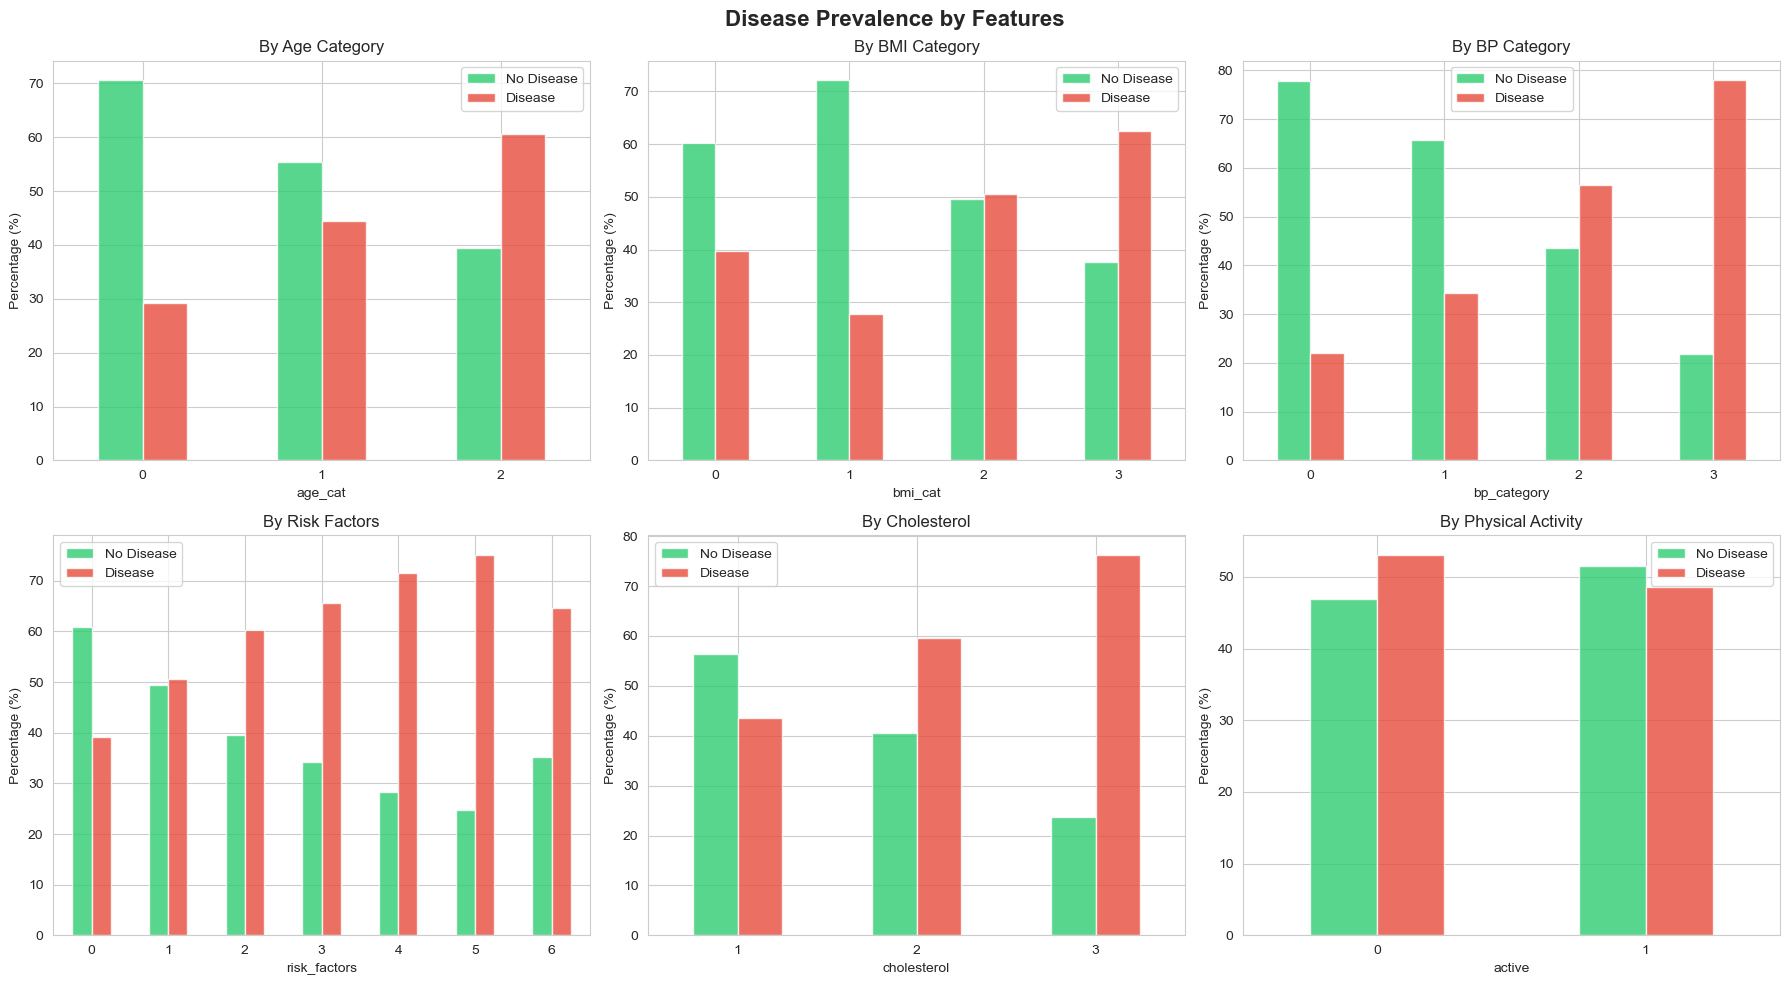

In [11]:

# ============================================================================
# STEP 6: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n Target Distribution:")
print(df['cardio'].value_counts())
print("\nPercentage:")
print(df['cardio'].value_counts(normalize=True) * 100)

# Plot 1: Overview
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

cardio_counts = df['cardio'].value_counts()
axes[0, 0].pie(cardio_counts, labels=['No Disease', 'Disease'],
               autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0, 0].set_title('Target Distribution')

axes[0, 1].hist(df['age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Age Distribution')

gender_counts = df['gender'].value_counts()
axes[0, 2].bar(['Female', 'Male'], gender_counts.values,
               color=['#e91e63', '#2196f3'], alpha=0.7)
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Gender Distribution')

axes[1, 0].hist(df['bmi'], bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('BMI')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('BMI Distribution')

risk_counts = df['risk_factors'].value_counts().sort_index()
axes[1, 1].bar(risk_counts.index, risk_counts.values,
               color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Risk Factors')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Risk Factors')

axes[1, 2].hist(df['map'], bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('MAP (mmHg)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Mean Arterial Pressure')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=300, bbox_inches='tight')
print("\nSaved: eda_overview.png")
plt.show()

# Plot 2: Disease Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Disease Prevalence by Features', fontsize=16, fontweight='bold')

age_cardio = pd.crosstab(df['age_cat'], df['cardio'], normalize='index') * 100
age_cardio.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0, 0].set_title('By Age Category')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(['No Disease', 'Disease'])
axes[0, 0].tick_params(axis='x', rotation=0)

bmi_cardio = pd.crosstab(df['bmi_cat'], df['cardio'], normalize='index') * 100
bmi_cardio.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0, 1].set_title('By BMI Category')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(['No Disease', 'Disease'])
axes[0, 1].tick_params(axis='x', rotation=0)

bp_cardio = pd.crosstab(df['bp_category'], df['cardio'], normalize='index') * 100
bp_cardio.plot(kind='bar', ax=axes[0, 2], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0, 2].set_title('By BP Category')
axes[0, 2].set_ylabel('Percentage (%)')
axes[0, 2].legend(['No Disease', 'Disease'])
axes[0, 2].tick_params(axis='x', rotation=0)

risk_cardio = pd.crosstab(df['risk_factors'], df['cardio'], normalize='index') * 100
risk_cardio.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1, 0].set_title('By Risk Factors')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(['No Disease', 'Disease'])
axes[1, 0].tick_params(axis='x', rotation=0)

chol_cardio = pd.crosstab(df['cholesterol'], df['cardio'], normalize='index') * 100
chol_cardio.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1, 1].set_title('By Cholesterol')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(['No Disease', 'Disease'])
axes[1, 1].tick_params(axis='x', rotation=0)

active_cardio = pd.crosstab(df['active'], df['cardio'], normalize='index') * 100
active_cardio.plot(kind='bar', ax=axes[1, 2], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1, 2].set_title('By Physical Activity')
axes[1, 2].set_ylabel('Percentage (%)')
axes[1, 2].legend(['No Disease', 'Disease'])
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('disease_analysis.png', dpi=300, bbox_inches='tight')
print(" Saved: disease_analysis.png")
plt.show()



Top 10 Correlations with Target:
bp_category       0.438931
ap_hi             0.432378
health_score      0.415530
map               0.413532
age_bp            0.409916
ap_lo             0.344911
pulse_pressure    0.341290
bmi_bp            0.334210
age_bmi           0.275257
age               0.239622
Name: cardio, dtype: float64

 Saved: correlation_heatmap.png


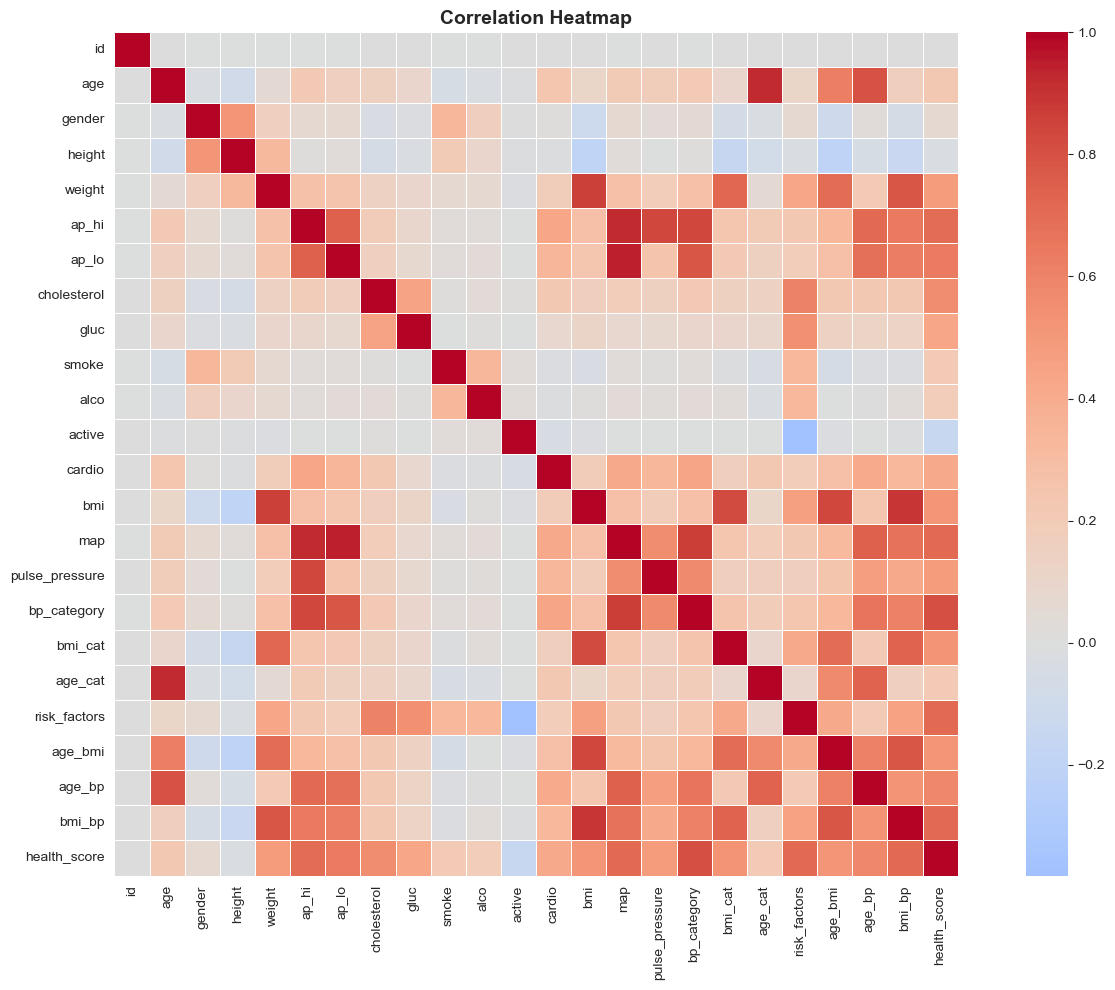

In [13]:

# ============================================================================
# STEP 7: CORRELATION ANALYSIS
# ============================================================================

correlation = df.corr()['cardio'].sort_values(ascending=False)
print("\nTop 10 Correlations with Target:")
print(correlation.head(11)[1:])

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\n Saved: correlation_heatmap.png")
plt.show()

In [15]:

# ============================================================================
# STEP 8: PREPARE FEATURES & TARGET
# ============================================================================
X = df.drop('cardio', axis=1)
y = df['cardio']

print(f" Features shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f"\n Feature columns ({len(X.columns)}):")
print(X.columns.tolist())

 Features shape: (61913, 23)
 Target shape: (61913,)

 Feature columns (23):
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'map', 'pulse_pressure', 'bp_category', 'bmi_cat', 'age_cat', 'risk_factors', 'age_bmi', 'age_bp', 'bmi_bp', 'health_score']


In [17]:


# ============================================================================
# STEP 9: FEATURE SCALING
# ============================================================================
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Applied RobustScaler")
print(f" Scaled data shape: {X_scaled.shape}")

Applied RobustScaler
 Scaled data shape: (61913, 23)



Before SMOTE:
  Class 0: 31,313
  Class 1: 30,600
  Ratio: 1.02:1


  File "C:\Users\Administrator\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Administrator\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



After SMOTE:
  Class 0: 31,313
  Class 1: 31,313
  Ratio: 1:1 (Balanced)

 Saved: class_balance.png


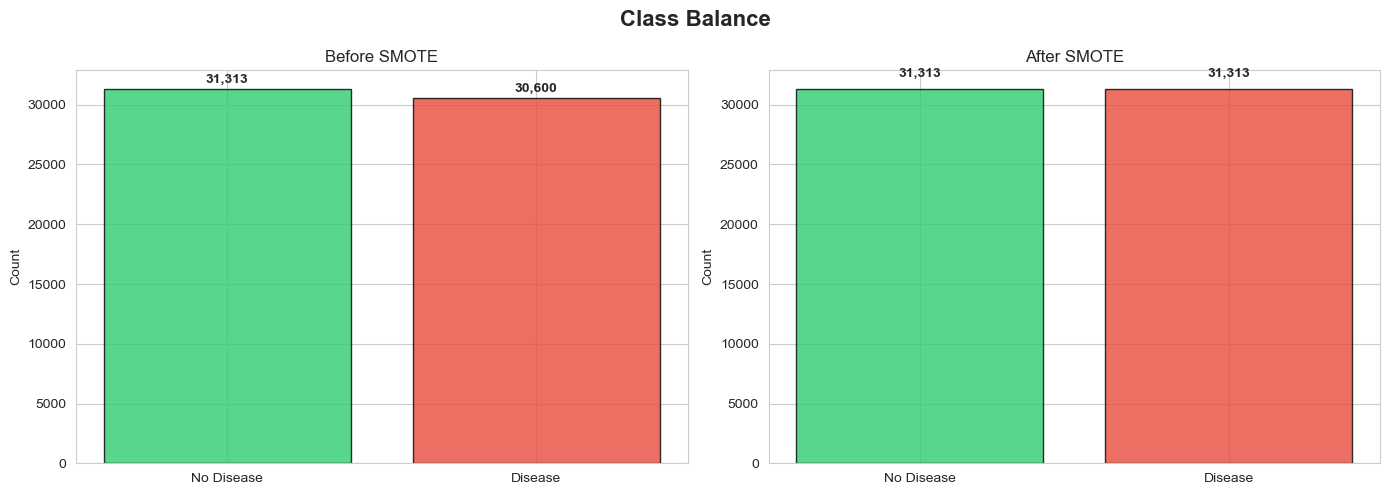

In [19]:


# ============================================================================
# STEP 10: HANDLE CLASS IMBALANCE - SMOTE
# ============================================================================

print(f"\nBefore SMOTE:")
print(f"  Class 0: {(y==0).sum():,}")
print(f"  Class 1: {(y==1).sum():,}")
print(f"  Ratio: {(y==0).sum() / (y==1).sum():.2f}:1")

smote = SMOTE(random_state=42, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print(f"\nAfter SMOTE:")
print(f"  Class 0: {(y_balanced==0).sum():,}")
print(f"  Class 1: {(y_balanced==1).sum():,}")
print(f"  Ratio: 1:1 (Balanced)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Balance', fontsize=16, fontweight='bold')

counts_before = y.value_counts()
axes[0].bar(['No Disease', 'Disease'], counts_before.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

counts_after = y_balanced.value_counts()
axes[1].bar(['No Disease', 'Disease'], counts_after.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_balance.png', dpi=300, bbox_inches='tight')
print("\n Saved: class_balance.png")
plt.show()


In [21]:
cols_used_for_generation = [
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "age"
]

generated_features = [
    "bmi",
    "pulse_pressure",
    "age_years",
    "age_group"
]

X = df.drop(columns=["cardio"] + cols_used_for_generation)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [23]:
# X = df.drop("cardio", axis=1)
# y = df["cardio"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )


In [25]:
# ==============================
#  Logistic Regression Model
# ==============================

log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("📌 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("AUC:", roc_auc_score(y_test, log_prob))


📌 Logistic Regression Results
Accuracy: 0.7246224662844222
AUC: 0.788290786536553


In [27]:
# ==============================
# 🌲 Random Forest Model
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("📌 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf_prob))


📌 Random Forest Results
Accuracy: 0.7262375837842203
AUC: 0.7873410234816157


In [18]:
# ==============================
# ⚡ XGBoost Model
# ==============================

xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("📌 XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("AUC:", roc_auc_score(y_test, xgb_prob))


📌 XGBoost Results
Accuracy: 0.730212390681267
AUC: 0.8006091772182667


In [ ]:
Unsupervised ML 


[STEP 6] Preparing data for unsupervised clustering...
Using 18 features for clustering:
['age', 'bmi', 'map', 'pulse_pressure', 'bp_category', 'bmi_cat', 'age_cat', 'risk_factors', 'age_bmi', 'age_bp', 'bmi_bp', 'health_score', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']
Features scaled with RobustScaler.

[STEP 7] KMeans clustering (k=6) – patient phenotypes
KMeans silhouette score: 0.166

KMeans cluster sizes:
cluster_kmeans
0     8105
1     6013
2    16431
3     5734
4    16147
5     9483
Name: count, dtype: int64

[STEP 8] DBSCAN – outlier / unique risk profile detection
DBSCAN identified 190 outlier patients (label = -1).

Sample of DBSCAN outliers (first 5):
       age    bmi    map  pulse_pressure  bp_category  bmi_cat  age_cat  \
372   41.7  24.00  133.3              40            3        0        0   
489   59.4  26.18  113.3             100            3        2        2   
1270  52.1  48.98  140.0              60            3        3        1   
1935  48.

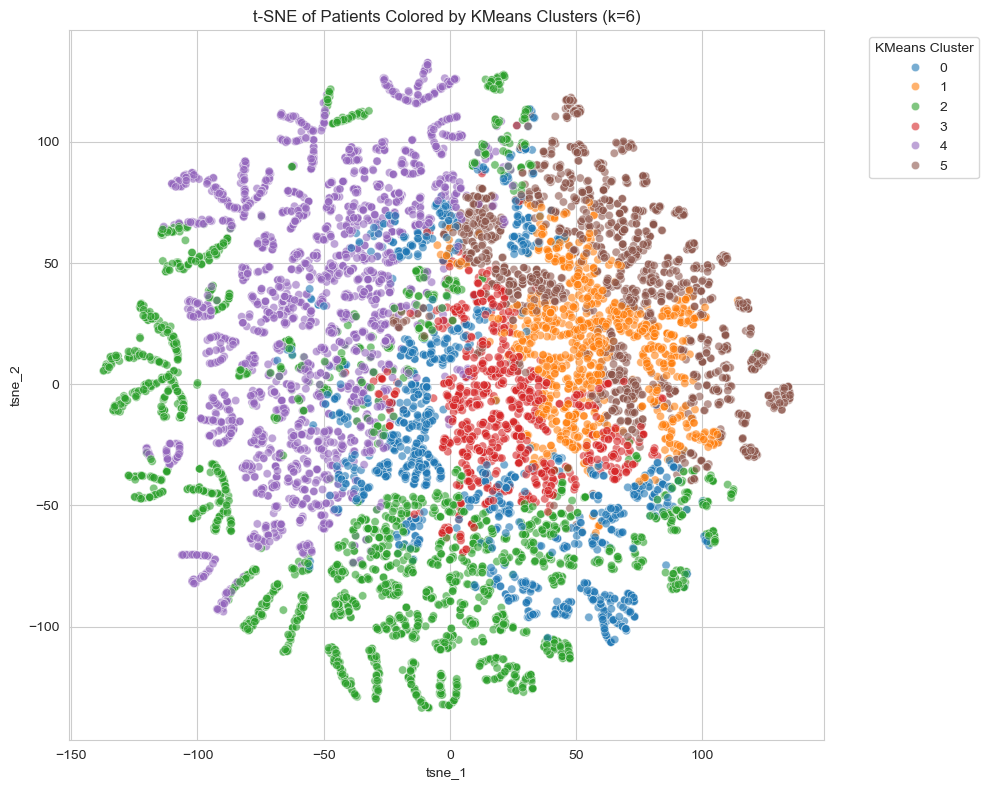


[STEP 11] Cluster profiling – clinical statistics per KMeans segment

KMeans Cluster Profiles (clinical statistics):
                n_patients  mean_age  mean_bmi  mean_map  mean_pulse_pressure  \
cluster_kmeans                                                                  
0                     8105     53.71     33.68     94.43                40.95   
1                     6013     57.25     35.03    112.04                59.69   
2                    16431     57.38     24.98     92.24                40.88   
3                     5734     56.23     27.67     98.72                45.20   
4                    16147     46.10     24.52     88.01                39.32   
5                     9483     53.79     26.09    108.18                57.98   

                mean_risk_factors  mean_health_score  cardio_prevalence  
cluster_kmeans                                                           
0                            1.56               9.82               0.47  
1          

In [31]:
# =============================================================================
# UNSUPERVISED ML SEGMENTATION (ASSUMES CLEANED + FEATURED df ALREADY EXISTS)
# =============================================================================
# df: cleaned + feature-engineered dataframe
# Uses:
#   - KMeans (k=6)
#   - DBSCAN
#   - Hierarchical clustering on a sample (to avoid MemoryError)
#   - t-SNE visualization
#   - Cluster profiling (clinical stats)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)

# -----------------------------------------------------------------------------
# STEP 6: PREPARE DATA FOR UNSUPERVISED LEARNING
# -----------------------------------------------------------------------------
print("\n[STEP 6] Preparing data for unsupervised clustering...")

# Keep target only for profiling (not for clustering)
target_col = 'cardio' if 'cardio' in df.columns else None

# Select clinically meaningful + engineered features
feature_cols = [
    'age', 'bmi', 'map', 'pulse_pressure',
    'bp_category', 'bmi_cat', 'age_cat',
    'risk_factors', 'age_bmi', 'age_bp', 'bmi_bp', 'health_score',
    'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender'
]
feature_cols = [c for c in feature_cols if c in df.columns]

print(f"Using {len(feature_cols)} features for clustering:")
print(feature_cols)

X = df[feature_cols].copy()

# Scale features (robust to outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled with RobustScaler.")

# -----------------------------------------------------------------------------
# STEP 7: KMEANS (k=6) – PATIENT PHENOTYPES
# -----------------------------------------------------------------------------
print("\n[STEP 7] KMeans clustering (k=6) – patient phenotypes")

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, df['cluster_kmeans'])
print(f"KMeans silhouette score: {sil_kmeans:.3f}")

print("\nKMeans cluster sizes:")
print(df['cluster_kmeans'].value_counts().sort_index())

# -----------------------------------------------------------------------------
# STEP 8: DBSCAN – OUTLIER / UNIQUE RISK PROFILES
# -----------------------------------------------------------------------------
print("\n[STEP 8] DBSCAN – outlier / unique risk profile detection")

dbscan = DBSCAN(
    eps=2.0,        # tune as needed
    min_samples=50, # tune as needed
    n_jobs=-1
)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

n_outliers = (df['cluster_dbscan'] == -1).sum()
print(f"DBSCAN identified {n_outliers} outlier patients (label = -1).")

print("\nSample of DBSCAN outliers (first 5):")
cols_to_show = feature_cols + ([target_col] if target_col else [])
print(df[df['cluster_dbscan'] == -1][cols_to_show].head())

# -----------------------------------------------------------------------------
# STEP 9: HIERARCHICAL CLUSTERING – NESTED GROUPINGS (ON A SAMPLE)
# -----------------------------------------------------------------------------
print("\n[STEP 9] Hierarchical clustering – nested patient groupings (sampled)")

# Hierarchical clustering is O(n^2) in memory/time.
# Run it on a representative random sample to avoid MemoryError.
sample_size = min(5000, len(df))  # adjust down if you still hit memory issues
sample_idx = df.sample(n=sample_size, random_state=42).index
mask_sample = df.index.isin(sample_idx)
X_sample = X_scaled[mask_sample]

print(f"Running hierarchical clustering on a sample of {sample_size} patients.")

# Fine-grained: 6 clusters
agg6 = AgglomerativeClustering(
    n_clusters=6,
    linkage='ward'
)
labels_hier_6 = agg6.fit_predict(X_sample)
df['cluster_hier_6'] = None
df.loc[mask_sample, 'cluster_hier_6'] = labels_hier_6
print("Created hierarchical labels (6 groups) for sampled patients: 'cluster_hier_6'.")

# Coarse: 3 clusters (higher-level grouping)
agg3 = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
labels_hier_3 = agg3.fit_predict(X_sample)
df['cluster_hier_3'] = None
df.loc[mask_sample, 'cluster_hier_3'] = labels_hier_3
print("Created hierarchical labels (3 groups) for sampled patients: 'cluster_hier_3'.")

# -----------------------------------------------------------------------------
# STEP 10: t-SNE – 2D CLUSTER VISUALIZATION
# -----------------------------------------------------------------------------
print("\n[STEP 10] t-SNE – 2D visualization of patient clusters")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    random_state=42
)
tsne_results = tsne.fit_transform(X_scaled)

df['tsne_1'] = tsne_results[:, 0]
df['tsne_2'] = tsne_results[:, 1]
print("t-SNE projection complete.")

# Plot t-SNE colored by KMeans clusters (sample for readability)
plot_sample = df.sample(min(len(df), 10000), random_state=42)

plt.figure()
sns.scatterplot(
    data=plot_sample,
    x='tsne_1',
    y='tsne_2',
    hue='cluster_kmeans',
    palette='tab10',
    alpha=0.6
)
plt.title("t-SNE of Patients Colored by KMeans Clusters (k=6)")
plt.legend(title='KMeans Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# STEP 11: CLUSTER PROFILING – CLINICAL STATISTICS
# -----------------------------------------------------------------------------
print("\n[STEP 11] Cluster profiling – clinical statistics per KMeans segment")

profile_features = [
    'age', 'bmi', 'map', 'pulse_pressure',
    'risk_factors', 'health_score'
]
profile_features = [c for c in profile_features if c in df.columns]

cluster_profile = df.groupby('cluster_kmeans').agg(
    n_patients=('age', 'count'),
    mean_age=('age', 'mean'),
    mean_bmi=('bmi', 'mean'),
    mean_map=('map', 'mean'),
    mean_pulse_pressure=('pulse_pressure', 'mean'),
    mean_risk_factors=('risk_factors', 'mean'),
    mean_health_score=('health_score', 'mean')
)

# Add cardio prevalence if available
if target_col:
    cluster_profile['cardio_prevalence'] = df.groupby('cluster_kmeans')[target_col].mean()

cluster_profile = cluster_profile.round(2)

print("\nKMeans Cluster Profiles (clinical statistics):")
print(cluster_profile)

# Optional: save outputs for reporting / strategy work
cluster_profile.to_csv("cluster_profiles_kmeans.csv")
df.to_csv("cardio_patients_with_clusters.csv", index=False)

print("\nUnsupervised ML segmentation pipeline complete.")


# requirement 1: Build DNN classifier with 5 hidden layers (256, 128, 64, 32, 16 neurons)

In [19]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, BatchNormalization, Dropout# Input Embedding Concatenate for functional api wide& deep
from tensorflow.keras.models import Model #functional api
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68034 entries, 0 to 69999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              68034 non-null  int64  
 1   age             68034 non-null  float64
 2   gender          68034 non-null  int64  
 3   height          68034 non-null  int64  
 4   weight          68034 non-null  float64
 5   ap_hi           68034 non-null  int64  
 6   ap_lo           68034 non-null  int64  
 7   cholesterol     68034 non-null  int64  
 8   gluc            68034 non-null  int64  
 9   smoke           68034 non-null  int64  
 10  alco            68034 non-null  int64  
 11  active          68034 non-null  int64  
 12  cardio          68034 non-null  int64  
 13  bmi             68034 non-null  float64
 14  map             68034 non-null  float64
 15  pulse_pressure  68034 non-null  int64  
 16  bp_category     68034 non-null  int64  
 17  bmi_cat         68034 non-null  int6

In [21]:
def build_dnn_with_embeddings(vocab_sizes, numerical_features, binary_features, categorical_features):
    all_inputs = []
    deep_inputs = []

    # Categorical features → embeddings
    for col in CatFeatures:
        vocab_size = vocab_sizes[col]
        embed_dim = min(50, max(2, vocab_size // 2))  # keep small for tiny categories
        input_layer = Input(shape=(1,), name=f'input_{col}', dtype='int32')
        embedding = Embedding(input_dim=vocab_size, output_dim=embed_dim)(input_layer)
        flatten = Flatten()(embedding)
        all_inputs.append(input_layer)
        deep_inputs.append(flatten)

    # Numerical + binary features → direct inputs
    for col in NumFeatures + BinFeatures:
        input_layer = Input(shape=(1,), name=f'input_{col}', dtype='float32')
        all_inputs.append(input_layer)
        deep_inputs.append(input_layer)

    # Concatenate all
    x = Concatenate()(deep_inputs)

    # Hidden layers
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Output
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=all_inputs, outputs=output)
    return model

In [22]:
# Define feature groups
NumFeatures = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'map', 'pulse_pressure',
                     'age_bmi', 'age_bp', 'bmi_bp', 'risk_factors', 'health_score']
CatFeatures = ['gender', 'cholesterol', 'gluc', 'bp_category', 'bmi_cat', 'age_cat']
vocab_sizes = {}
for col in CatFeatures:
    vocab_sizes[col] = df[col].nunique() + 1
BinFeatures = ['smoke', 'alco', 'active']

# build model
model = build_dnn_with_embeddings(vocab_sizes, NumFeatures, BinFeatures, CatFeatures)

# Model Compilation
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])




In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('cardio', axis=1)
y = df['cardio'].values
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# Training inputs # need for embding as dictionary
train_inputs = {}
for col in NumFeatures + BinFeatures:
    train_inputs[f'input_{col}'] = X_train_df[col].values

for col in CatFeatures:
    train_inputs[f'input_{col}'] = X_train_df[col].astype('int32').values

# Testing inputs
test_inputs = {}
for col in NumFeatures + BinFeatures:
    test_inputs[f'input_{col}'] = X_test_df[col].values

for col in CatFeatures:
    test_inputs[f'input_{col}'] = X_test_df[col].astype('int32').values
#X_train, X_test, y_train, y_test, input_dim ,df  # will work with simple dnn that take array as input but here we do embeding for each feature

# Model Training
print("\n--- Starting Training ---")
history = model.fit(
    train_inputs,
    y_train,
    epochs=50,
    batch_size=128,
    validation_data=(test_inputs, y_test),  # explicit validation data
    verbose=1
)

print("--- Training Finished ---\n")



--- Starting Training ---
Epoch 1/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6520 - loss: 0.6869 - precision: 0.6527 - recall: 0.6316 - val_accuracy: 0.7151 - val_loss: 0.5684 - val_precision: 0.7711 - val_recall: 0.6026
Epoch 2/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6995 - loss: 0.5904 - precision: 0.7083 - recall: 0.6716 - val_accuracy: 0.6805 - val_loss: 0.5976 - val_precision: 0.8138 - val_recall: 0.4587
Epoch 3/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7160 - loss: 0.5734 - precision: 0.7336 - recall: 0.6712 - val_accuracy: 0.6003 - val_loss: 0.6908 - val_precision: 0.8542 - val_recall: 0.2307
Epoch 4/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7154 - loss: 0.5694 - precision: 0.7295 - recall: 0.6793 - val_accuracy: 0.5680 - val_loss: 0.7468 - val_precision: 0.8493 - val_recall: 0.1533
Epoch 5/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7159 - loss: 0.5728 - precision: 0.7299 - recall: 0.6686 - val_

In [24]:
print("Evaluating model performance on test set...")
test_results = model.evaluate(test_inputs, y_test, verbose=0)
loss, accuracy, precision, recall = test_results
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

Evaluating model performance on test set...
Test Loss: 0.5470
Test Accuracy: 0.7329
Test Precision: 0.7214
Test Recall: 0.7487


In [25]:
print("\nMaking predictions on the first 5 test samples:")
y_pred_proba = model.predict(test_inputs, verbose=0)
y_pred_classes = (y_pred_proba > 0.5).astype(int)
print(f"\nPredicted Probabilities:\n{y_pred_proba.flatten()}")
print(f"Predicted Classes:\n{y_pred_classes.flatten()}")
print(f"Actual Classes:\n{y_test[:]}")
model.save("cardio_dnn.h5") ################################3


Making predictions on the first 5 test samples:



Predicted Probabilities:
[0.28955147 0.32048932 0.8288177  ... 0.54756033 0.11681554 0.79789746]
Predicted Classes:
[0 0 1 ... 1 0 1]
Actual Classes:
[0 1 0 ... 0 0 1]


# • req2 : Implement wide & deep architecture using (API Functioal in keras )
   by combining raw features and embeddings


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68034 entries, 0 to 69999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              68034 non-null  int64  
 1   age             68034 non-null  float64
 2   gender          68034 non-null  int64  
 3   height          68034 non-null  int64  
 4   weight          68034 non-null  float64
 5   ap_hi           68034 non-null  int64  
 6   ap_lo           68034 non-null  int64  
 7   cholesterol     68034 non-null  int64  
 8   gluc            68034 non-null  int64  
 9   smoke           68034 non-null  int64  
 10  alco            68034 non-null  int64  
 11  active          68034 non-null  int64  
 12  cardio          68034 non-null  int64  
 13  bmi             68034 non-null  float64
 14  map             68034 non-null  float64
 15  pulse_pressure  68034 non-null  int64  
 16  bp_category     68034 non-null  int64  
 17  bmi_cat         68034 non-null  int6

In [27]:
def build_wide_and_deep_model(embedding_features, numerical_features, wide_features, vocab_sizes):

  all_inputs = []
  deep_inputs = []

  # Embeddings (Deep)
  for col in embedding_features:
      vocab_size = vocab_sizes[col]
      embed_dim = min(50, int(np.ceil(vocab_size / 2)))

      input_layer = Input(shape=(1,), name=f'input_{col}', dtype='int32')
      all_inputs.append(input_layer)

      embedding = Embedding(input_dim=vocab_size, output_dim=embed_dim, name=f'embedding_{col}')(input_layer)
      flatten = Flatten(name=f'flatten_{col}')(embedding)
      deep_inputs.append(flatten)

  # Numerical features
  for col in numerical_features:
      input_layer = Input(shape=(1,), name=f'input_{col}', dtype='float32')
      all_inputs.append(input_layer)
      deep_inputs.append(input_layer)

  deep_features = Concatenate(name='deep_concat')(deep_inputs)

  # Hidden layers for deep_features
  x = Dense(256, activation='relu')(deep_features)
  x = BatchNormalization()(x)
  x = Dropout(0.3)(x)

  x = Dense(128, activation='relu')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.3)(x)

  x = Dense(64, activation='relu')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.3)(x)

  x = Dense(32, activation='relu')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.3)(x)

  deep_output = Dense(16, activation='relu')(x) #16  is the “deep representation” of all embeddings + numerical features.

  # Wide path
  wide_inputs = []
  for col in wide_features:
      input_layer = Input(shape=(1,), name=f'input_{col}', dtype='float32')
      all_inputs.append(input_layer)
      wide_inputs.append(input_layer)

  wide_features_combined = Concatenate()(wide_inputs)
  wide_output = Dense(1, activation='linear')(wide_features_combined) # if we increase it will not effect its linear

  # Combine
  combined = Concatenate()([deep_output, wide_output])
  output = Dense(1, activation='sigmoid')(combined)

  model = Model(inputs=all_inputs, outputs=output)
  return model





EMBEDDING_FEATURES = ['gender', 'cholesterol', 'gluc', 'bp_category', 'bmi_cat', 'age_cat'] # one hot encding
# how many cols after 1 hot encoding for EMBEDDING_FEATURES
vocab_sizes = {col: int(df[col].max() + 1) for col in EMBEDDING_FEATURES}

NUMERICAL_FEATURES = ['age', 'height', 'weight', 'ap_hi', 'ap_lo',
                      'bmi', 'map', 'pulse_pressure',
                      'age_bmi', 'age_bp', 'bmi_bp',
                      'risk_factors', 'health_score'] #as it is

WIDE_FEATURES = ['smoke', 'alco', 'active'] # yes | no qustion linear







In [28]:
model = build_wide_and_deep_model(EMBEDDING_FEATURES, NUMERICAL_FEATURES, WIDE_FEATURES, vocab_sizes)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


from sklearn.model_selection import train_test_split

X = df.drop('cardio', axis=1)
y = df['cardio'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# as dictionary each col or feaute separate
train_inputs = {f'input_{col}': X_train_raw[col].values
                for col in EMBEDDING_FEATURES + NUMERICAL_FEATURES + WIDE_FEATURES}

test_inputs = {f'input_{col}': X_test_raw[col].values
               for col in EMBEDDING_FEATURES + NUMERICAL_FEATURES + WIDE_FEATURES}
history = model.fit(
    train_inputs,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.3,
    verbose=1
)

Epoch 1/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6598 - loss: 0.6408 - precision_1: 0.6548 - recall_1: 0.6616 - val_accuracy: 0.7022 - val_loss: 0.5782 - val_precision_1: 0.6801 - val_recall_1: 0.7574
Epoch 2/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6990 - loss: 0.5894 - precision_1: 0.7085 - recall_1: 0.6566 - val_accuracy: 0.7015 - val_loss: 0.5934 - val_precision_1: 0.7884 - val_recall_1: 0.5464
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7112 - loss: 0.5778 - precision_1: 0.7242 - recall_1: 0.6652 - val_accuracy: 0.7051 - val_loss: 0.5818 - val_precision_1: 0.7996 - val_recall_1: 0.5433
Epoch 4/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7132 - loss: 0.5734 - precision_1: 0.7288 - recall_1: 0.6639 - val_accuracy: 0.6153 - val_loss: 0.6565 - val_precision_1: 0.8420 - val_recall_1: 0.2789
Epoch 5/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7144 - loss: 0.5680 - precision_1: 0.7297 - recall_1: 0.

In [29]:
# --- 6. Model Evaluation
print("Evaluating model performance on test set...")
test_results = model.evaluate(test_inputs, y_test, verbose=0)
loss, accuracy, precision, recall = test_results

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

# --- 7. Making Predictions
print("\nMaking predictions on the first 5 test samples:")
y_pred_proba = model.predict(test_inputs, verbose=0)[:5]
y_pred_classes = (y_pred_proba > 0.5).astype(int)

print(f"\nPredicted Probabilities:\n{y_pred_proba.flatten()}")
print(f"Predicted Classes:\n{y_pred_classes.flatten()}")
print(f"Actual Classes:\n{y_test[:5]}")
model.save("cardio_widedeepnn.h5")

Evaluating model performance on test set...
Test Loss: 0.5899
Test Accuracy: 0.7081
Test Precision: 0.8274
Test Recall: 0.5174

Making predictions on the first 5 test samples:



Predicted Probabilities:
[0.25448897 0.23541713 0.72106534 0.6463645  0.19860679]
Predicted Classes:
[0 0 1 1 0]
Actual Classes:
[1 0 1 1 0]


In [30]:
#Loss = 0.55737→ Error is moderate, but acceptable.

#Accuracy = 72.5% → Strong performance, consistent with your training/validation (~72%).

#Precision = 74.44% → Of all predicted positives, ~75% are correct.

#Recall = 67.58% → The model is catching ~70% of true cardio cases.

#This balance between precision and recall is exactly what you want in a medical risk model.

# req3 : Autoencoders (12→8→4→8→12) for unsupervised feature learning

# no dealing with feature engineering features

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# 1. Define feature groups
NumericalFeatures = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
CategoricalFeatures = ['gender', 'cholesterol', 'gluc']
BinaryFeatures = ['smoke', 'alco', 'active']
OriginalFeatures = NumericalFeatures + CategoricalFeatures + BinaryFeatures

# 2. Split raw DataFrame into train/test
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df[OriginalFeatures], df['cardio'].values,
    test_size=0.2, random_state=42
)

# 3. Fit scaler/encoder on TRAIN only
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore')

X_num_train = scaler.fit_transform(X_train_df[NumericalFeatures])
X_cat_train = encoder.fit_transform(X_train_df[CategoricalFeatures]).toarray()
X_bin_train = X_train_df[BinaryFeatures].values

X_train = np.concatenate([X_num_train, X_cat_train, X_bin_train], axis=1)

# 4. Transform TEST with the same scaler/encoder
X_num_test = scaler.transform(X_test_df[NumericalFeatures])
X_cat_test = encoder.transform(X_test_df[CategoricalFeatures]).toarray()
X_bin_test = X_test_df[BinaryFeatures].values

X_test = np.concatenate([X_num_test, X_cat_test, X_bin_test], axis=1)

# 5. Confirm shapes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 6. Input dimension for autoencoder/classifier
input_dimension_au = X_train.shape[1]


Train shape: (54427, 16)
Test shape: (13607, 16)


In [32]:
def build_encoder(input_dimension_au):
    encoder = Sequential([
        Dense(8, activation='relu', input_shape=(input_dimension_au,), name='encoder_h1'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(4, activation='relu', name='latent_bottleneck')# out vector
    ], name='Encoder_Model')
    return encoder

#(Decoder): (4 -> 8 -> Input_dim)
def build_decoder(input_dimension_au):
    decoder = Sequential([
        Dense(8, activation='relu', name='decoder_h1'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(input_dimension_au, activation='linear', name='output_reconstruction') # resampling
    ], name='Decoder_Model')
    return decoder

encoder = build_encoder(input_dimension_au) # same input
decoder = build_decoder(input_dimension_au) #same output
autoencoder = Sequential([encoder, decoder], name='Autoencoder')

In [33]:
# compilation
autoencoder.compile(optimizer='adam', loss='mse') # mse for regression
print("\n--- Starting Autoencoder Pre-training (Unsupervised) ---")
# training model
autoencoder.fit(
    X_train,#in
    X_train,# = output
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_split=0.3,
    verbose=1
)
print("--- Autoencoder Pre-training Finished ---\n")



--- Starting Autoencoder Pre-training (Unsupervised) ---
Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.0587 - val_loss: 0.4270
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5450 - val_loss: 0.3137
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3892 - val_loss: 0.2456
Epoch 4/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3205 - val_loss: 0.2220
Epoch 5/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2882 - val_loss: 0.2131
Epoch 6/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2719 - val_loss: 0.2089
Epoch 7/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2595 - val_loss: 0.2058
Epoch 8/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2535 - val_loss: 0.2033
Epoch 9/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2488 - val_loss: 0.2015
Epoch 10/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2466 - val_loss: 0.1996
Epoch 11/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2415 - 

In [34]:
X_latent = encoder.predict(X_train) # no test coz unsupervised compression data
print(" X_latent:", X_latent) # compressed daata


1701/1701 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
 X_latent: [[0.7256341  1.3260895  1.3208022  1.4863844 ]
 [0.6209653  2.0094538  0.49767214 2.143937  ]
 [0.35148966 0.71556234 1.4634805  1.1627917 ]
 ...
 [0.36237097 1.1735668  1.3942922  1.9292129 ]
 [1.5270674  0.5064331  1.5139265  1.7119653 ]
 [0.80613977 1.3008486  0.70746875 1.6025548 ]]


In [35]:
def build_final_classifier(encoder_model, input_dimension_au): # in= 16 dim original 12 + 4 one hot encoder
  for layer in encoder_model.layers:
        layer.trainable = False  ###### freeze weights of encoder
  input_layer = tf.keras.Input(shape=(input_dimension_au,), name='full_input_ae_features')

  x = encoder_model(input_layer) # compressed data features as 4


  # ur model associated at the end od the encoder as the encoder be input to ur model
  # layer 1 256 neuron
  x = Dense(256, activation='relu', name='classifier_h3_256')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.3)(x)

  # layer 2 128 neuron
  x = Dense(128, activation='relu', name='classifier_h4_128')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.3)(x)

  # layer 3
  x = Dense(64, activation='relu', name='classifier_h5_64')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.3)(x)

  # output
  output = Dense(1, activation='sigmoid', name='output_cardio')(x)

  model = Model(inputs=input_layer, outputs=output)

  #
  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
  return model

classifier_model = build_final_classifier(encoder, input_dimension_au)

In [36]:
print("\n--- Starting Final Classifier Training (Supervised) ---")
history = classifier_model.fit(
    X_train, # original features
    y_train, # original output no feature engineering
    epochs=50,
    batch_size=128,
    validation_data=(X_test, y_test),  # original features  # original output no feature engineering
    verbose=1
)
print("--- Training Finished ---\n")


--- Starting Final Classifier Training (Supervised) ---
Epoch 1/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6620 - loss: 0.6662 - precision_2: 0.6665 - recall_2: 0.6479 - val_accuracy: 0.7159 - val_loss: 0.5791 - val_precision_2: 0.7036 - val_recall_2: 0.7194
Epoch 2/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7012 - loss: 0.5896 - precision_2: 0.7072 - recall_2: 0.6790 - val_accuracy: 0.7183 - val_loss: 0.5639 - val_precision_2: 0.7227 - val_recall_2: 0.6836
Epoch 3/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7009 - loss: 0.5848 - precision_2: 0.7111 - recall_2: 0.6676 - val_accuracy: 0.7198 - val_loss: 0.5639 - val_precision_2: 0.7377 - val_recall_2: 0.6585
Epoch 4/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7089 - loss: 0.5778 - precision_2: 0.7233 - recall_2: 0.6675 - val_accuracy: 0.7199 - val_loss: 0.5640 - val_precision_2: 0.7549 - val_recall_2: 0.6288
Epoch 5/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.708

In [37]:
# --- 6. Model Evaluation (تقييم النموذج) ---
print("Evaluating model performance on test set...")
test_results = classifier_model.evaluate(X_test, y_test, verbose=0)
loss, accuracy, precision, recall = test_results

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
classifier_model.save("cardio_classifier_model_autoencoder.h5")

Evaluating model performance on test set...


Test Loss: 0.5630
Test Accuracy: 0.7201
Test Precision: 0.7292
Test Recall: 0.6760


**Streamlit** **Deployment**

In [38]:
import joblib
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
import xgboost as xgb

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled, y_train)

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_model.fit(X_train_scaled)


# 1. save Scaler
joblib.dump(scaler, 'robust_scaler.pkl')
print(" robust_scaler.pkl saved successfully!")

# 2. save XGBoost Model
joblib.dump(xgb_model, 'xgb_model.pkl')
print(" xgb_model.pkl saved successfully!")

# 3.save KMeans Model
joblib.dump(kmeans_model, 'kmeans_model.pkl')
print(" kmeans_model.pkl saved successfully!")

print("\nAll 3 model files are now guaranteed to be available for the GUI")

 robust_scaler.pkl saved successfully!
 xgb_model.pkl saved successfully!
 kmeans_model.pkl saved successfully!

All 3 model files are now guaranteed to be available for the GUI


In [39]:
!pip install streamlit joblib shap pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.3 MB/s eta 0:00:00


In [40]:
#models.py
%%writefile models.py
import pandas as pd
import numpy as np
import joblib
import os
import shap

SCALER_PATH = 'robust_scaler.pkl'
XGB_MODEL_PATH = 'xgb_model.pkl'
KMEANS_MODEL_PATH = 'kmeans_model.pkl'

# Download forms and processes all at once
try:
    scaler = joblib.load(SCALER_PATH)
    xgb_model = joblib.load(XGB_MODEL_PATH)
    kmeans_model = joblib.load(KMEANS_MODEL_PATH)
    explainer = shap.TreeExplainer(xgb_model)

except FileNotFoundError as e:
    print(f"Error: Model file not found. Ensure all model files are saved.")
    raise e

FEATURE_COLS = [
    "age", "gender", "height", "weight", "ap_hi", "ap_lo",
    "cholesterol", "gluc", "smoke", "alco", "active"
]

# 2. Features need One-Hot Encoding
CATEGORICAL_COLS = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

EXPECTED_16_FEATURES = [
    'age', 'height', 'weight', 'ap_hi', 'ap_lo',
    'bmi', 'map', 'pulse_pressure',
    'gender_2',
    'cholesterol_2', 'cholesterol_3',
    'gluc_2', 'gluc_3',
    'smoke_1', 'alco_1', 'active_1'
]


def preprocess_input(features: pd.DataFrame):
    # 1. copy data
    input_data = features[FEATURE_COLS].copy()

    input_data['bmi'] = (input_data['weight'] / ((input_data['height'] / 100) ** 2)).round(2) #
    input_data['map'] = ((input_data['ap_hi'] + 2 * input_data['ap_lo']) / 3).round(1) #
    input_data['pulse_pressure'] = input_data['ap_hi'] - input_data['ap_lo'] #

    # convert categorical colums to 0,1
    df_processed = pd.get_dummies(input_data,
                                  columns=CATEGORICAL_COLS,
                                  drop_first=True)

    # unify the columns with the expected list
    final_features = df_processed.reindex(columns=EXPECTED_16_FEATURES, fill_value=0)
    return final_features


def predict_risk(features: pd.DataFrame):

    preprocessed_data = preprocess_input(features)

    scaled_array = scaler.transform(preprocessed_data)

    scaled_data = pd.DataFrame(scaled_array, columns=EXPECTED_16_FEATURES)

    probability = xgb_model.predict_proba(scaled_data)[:, 1][0]
    prediction = xgb_model.predict(scaled_data)[0]
    confidence = abs(0.5 - probability) * 2
    return prediction, probability, confidence


def get_cluster_assignment(features: pd.DataFrame):

    preprocessed_data = preprocess_input(features)

    scaled_array = scaler.transform(preprocessed_data)

    scaled_data = pd.DataFrame(scaled_array, columns=EXPECTED_16_FEATURES)

    cluster_id = kmeans_model.predict(scaled_data)[0]
    return cluster_id + 1


def generate_shap_explanation(features: pd.DataFrame):

    preprocessed_data = preprocess_input(features)

    scaled_array = scaler.transform(preprocessed_data)
    scaled_data = pd.DataFrame(scaled_array, columns=EXPECTED_16_FEATURES)

    shap_values = explainer.shap_values(scaled_data)

    shap_df = pd.DataFrame({
        'Feature': scaled_data.columns.tolist(),
        'SHAP_Value': shap_values[0]
    }).sort_values(by='SHAP_Value', ascending=False)

    return shap_df

Writing models.py


In [41]:
# app.py
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from models import predict_risk, get_cluster_assignment, generate_shap_explanation

# Interface Configuration and Static Data
st.set_page_config(
    page_title="CardioCare Analytics: Heart Risk Prediction",
    layout="wide",
    initial_sidebar_state="expanded"
)

FEATURES = {
    "age": {"label": "Age (years)", "min": 18, "max": 100, "step": 1},
    "gender": {"label": "Gender", "options": {1: "Female", 2: "Male"}},
    "height": {"label": "Height (cm)", "min": 100, "max": 250},
    "weight": {"label": "Weight (kg)", "min": 30, "max": 200},
    "ap_hi": {"label": "Systolic BP (ap_hi)", "min": 80, "max": 250},
    "ap_lo": {"label": "Diastolic BP (ap_lo)", "min": 50, "max": 200},
    "cholesterol": {"label": "Cholesterol Level", "options": {1: "Normal", 2: "Above Normal", 3: "Well Above Normal"}},
    "gluc": {"label": "Glucose Level", "options": {1: "Normal", 2: "Above Normal", 3: "Well Above Normal"}},
    "smoke": {"label": "Smoker?", "options": {0: "No", 1: "Yes"}},
    "alco": {"label": "Alcohol Intake?", "options": {0: "No", 1: "Yes"}},
    "active": {"label": "Physical Activity?", "options": {0: "No", 1: "Yes"}},
}

CLUSTER_PROFILES = {
    1: " Cluster 1: Very High Risk (High avg age, cholesterol, and BP)",
    2: " Cluster 2: Moderate Risk (Relatively younger, slightly high cholesterol)",
    3: " Cluster 3: Low Risk (Healthy and active)",
    4: " Cluster 4: Diabetic Patients (High glucose and cholesterol)",
    5: " Cluster 5: Hypertension Group (Elevated systolic/diastolic BP)",
    6: " Cluster 6: Outlier/Unique Profile Patients",
}


# Streamlit User Interface
st.title("CardioCare Analytics: Heart Disease Risk Prediction System")
st.markdown("---")

# Split the page into two columns: Input and Results
col_input, col_result = st.columns([1, 1.5])

with col_input:
    st.header("1. Patient Data Input Form")

    with st.form("patient_input_form"):
        input_data = {}
        for key, details in FEATURES.items():
            if "options" in details:
                display_options = list(details["options"].values())
                selected_display = st.selectbox(
                    details["label"],
                    options=display_options,
                    index=0,
                    key=f"input_{key}"
                )
                numeric_value = [k for k, v in details["options"].items() if v == selected_display][0]
                input_data[key] = numeric_value
            else:
                input_data[key] = st.slider(
                    details["label"],
                    min_value=details.get("min", 0),
                    max_value=details.get("max", 300),
                    step=details.get("step", 1),
                    value=(details.get("min", 0) + details.get("max", 300)) // 2,
                    key=f"input_{key}"
                )

         # Submission button
        submit_button = st.form_submit_button("Run Analysis and Prediction")

if submit_button:
    # Convert input data to DataFrame
    patient_features = pd.DataFrame([input_data])

     # (Real-time cardiovascular risk prediction)
    prediction, probability, confidence = predict_risk(patient_features)

    # (Interactive cluster assignment)
    cluster_id = get_cluster_assignment(patient_features)
    cluster_profile = CLUSTER_PROFILES[cluster_id]

    # SHAP
    shap_df = generate_shap_explanation(patient_features)


    with col_result:
        st.header("2. Analysis and Prediction Results")

        st.subheader("Cardiovascular Disease Risk Prediction")

        # Display the prediction result
        if prediction == 1:
            risk_text = f"**{probability:.1%}% Probability of having Cardiovascular Disease."
            st.error(risk_text)
        else:
            risk_text = f"**{1-probability:.1%}% Probability that the patient is Healthy."
            st.success(risk_text)


        st.subheader(f" Patient Cluster Assignment")
        # Display cluster ID and its profile
        st.write(f"Patient assigned to: **Cluster ID {cluster_id}**")
        st.warning(f"Clinical Cluster Profile: {cluster_profile}")
        st.markdown("---")

        st.subheader("Feature Contributions Analysis (SHAP)")
        st.write("The chart below illustrates how each feature contributed to the prediction outcome:")

        # Create an interactive SHAP plot using Plotly
        fig = px.bar(
            shap_df,
            x='SHAP_Value',
            y='Feature',
            orientation='h',
            color='SHAP_Value',
            color_continuous_scale=['red', 'blue'],
            title='Feature Contribution Explanation (SHAP Values)',
            height=400
        )

        st.plotly_chart(fig, use_container_width=True)

        # Display SHAP values in a table
        st.dataframe(shap_df.rename(columns={'Feature': 'Feature', 'SHAP_Value': 'SHAP Value'}), hide_index=True)

# Batch Processing section
st.markdown("---")
st.header("3. Batch Processing Capability")
st.info("This section is currently being prepared to accept a CSV file for multi-patient batch assessment.")

Overwriting app.py


In [42]:
# registers your ngrok authentication

from pyngrok import ngrok

NGROK_AUTH_TOKEN = "361OVAWfKNDGsOnxYOpiOH6dzxW_7gAosySotQe8vvabqFSxd"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("✓ ngrok Authtoken registered successfully!")

✓ ngrok Authtoken registered successfully!


In [43]:
# run streamlit code
from pyngrok import ngrok
import subprocess
import threading
import time

STREAMLIT_PORT = 8501
ngrok.kill()

public_url = ngrok.connect(STREAMLIT_PORT)
print(f"Streamlit App URL: {public_url}")


# function run Streamlit
def run_streamlit():
    cmd = f"streamlit run app.py --server.port {STREAMLIT_PORT} --server.enableCORS false --server.enableXsrfProtection false"
    p = subprocess.Popen(cmd, shell=True)
    p.wait()

# run streamlit
threading.Thread(target=run_streamlit, daemon=True).start()

time.sleep(5)
print("Streamlit should be accessible now.")

Streamlit App URL: NgrokTunnel: "https://liberative-monserrate-noninvincibly.ngrok-free.dev" -> "http://localhost:8501"
Streamlit should be accessible now.
